In [1]:
import scipy.io as sio

In [2]:
JR = sio.loadmat("../data/jasperRidge2_R198.mat")
JR_end = sio.loadmat("../data/jasperRidge2_end4.mat")

In [3]:
JR.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Region', 'SlectBands', 'nRow', 'nCol', 'nBand', 'maxValue', 'R'])

In [4]:
JR_end.keys()

dict_keys(['__header__', '__version__', '__globals__', 'cood', 'M', 'A'])

In [5]:
JR["R"].shape

(198, 10000)

In [6]:
JR_end["M"].shape

(198, 4)

In [7]:
JR_end["A"].shape

(4, 10000)

In [15]:
JR["nRow"], JR["nCol"], JR["nBand"]

(array([[100]], dtype=uint8), array([[100]], dtype=uint8), 198)

In [16]:
import numpy as np
JR["nBand"] = np.array([198])
JR["nBand"] = np.array([[198]], dtype=np.uint8)
sio.savemat("../data/jasperRidge2_R198_updated.mat", JR)

c:\Home\College\Honors\Implementations\UNMamba\venv\Lib\site-packages\scipy\io\matlab\_mio.py:319: MatWriteWarning: Starting field name with a underscore (__header__) is ignored
  MW.put_variables(mdict)
c:\Home\College\Honors\Implementations\UNMamba\venv\Lib\site-packages\scipy\io\matlab\_mio.py:319: MatWriteWarning: Starting field name with a underscore (__version__) is ignored
  MW.put_variables(mdict)
c:\Home\College\Honors\Implementations\UNMamba\venv\Lib\site-packages\scipy\io\matlab\_mio.py:319: MatWriteWarning: Starting field name with a underscore (__globals__) is ignored
  MW.put_variables(mdict)


### Cuprite

In [1]:
import scipy.io as sio

In [6]:
cuprite = sio.loadmat("../data/cuprite.mat")

In [7]:
print(cuprite.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X', 'M', 'P', 'H', 'W', 'C'])


In [8]:
print(cuprite["X"].shape)

(188, 512, 614)


In [10]:
print(cuprite["C"].item(), cuprite["H"].item(), cuprite["W"].item(), cuprite["P"].item())

188 512 614 4


### Chandrayaan

In [2]:
import scipy.io as sio

chan = sio.loadmat("../data/chandrayaan.mat")

In [3]:
print(chan.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Y'])


In [15]:
print(chan["Y"].shape)
print(chan["Y"].min(), chan["Y"].max())
print((chan["Y"] < 0).sum(), (chan["Y"] > 0).sum())

(85, 2995, 304)
-999.0 1.6278384
29510565 47880235


In [16]:
# Is it exactly -999?
print("Exactly -999:", (chan["Y"] == -999.0).sum())
print("Between -999 and 0:", ((chan["Y"] > -999) & (chan["Y"] < 0)).sum())

Exactly -999: 1820960
Between -999 and 0: 27689605


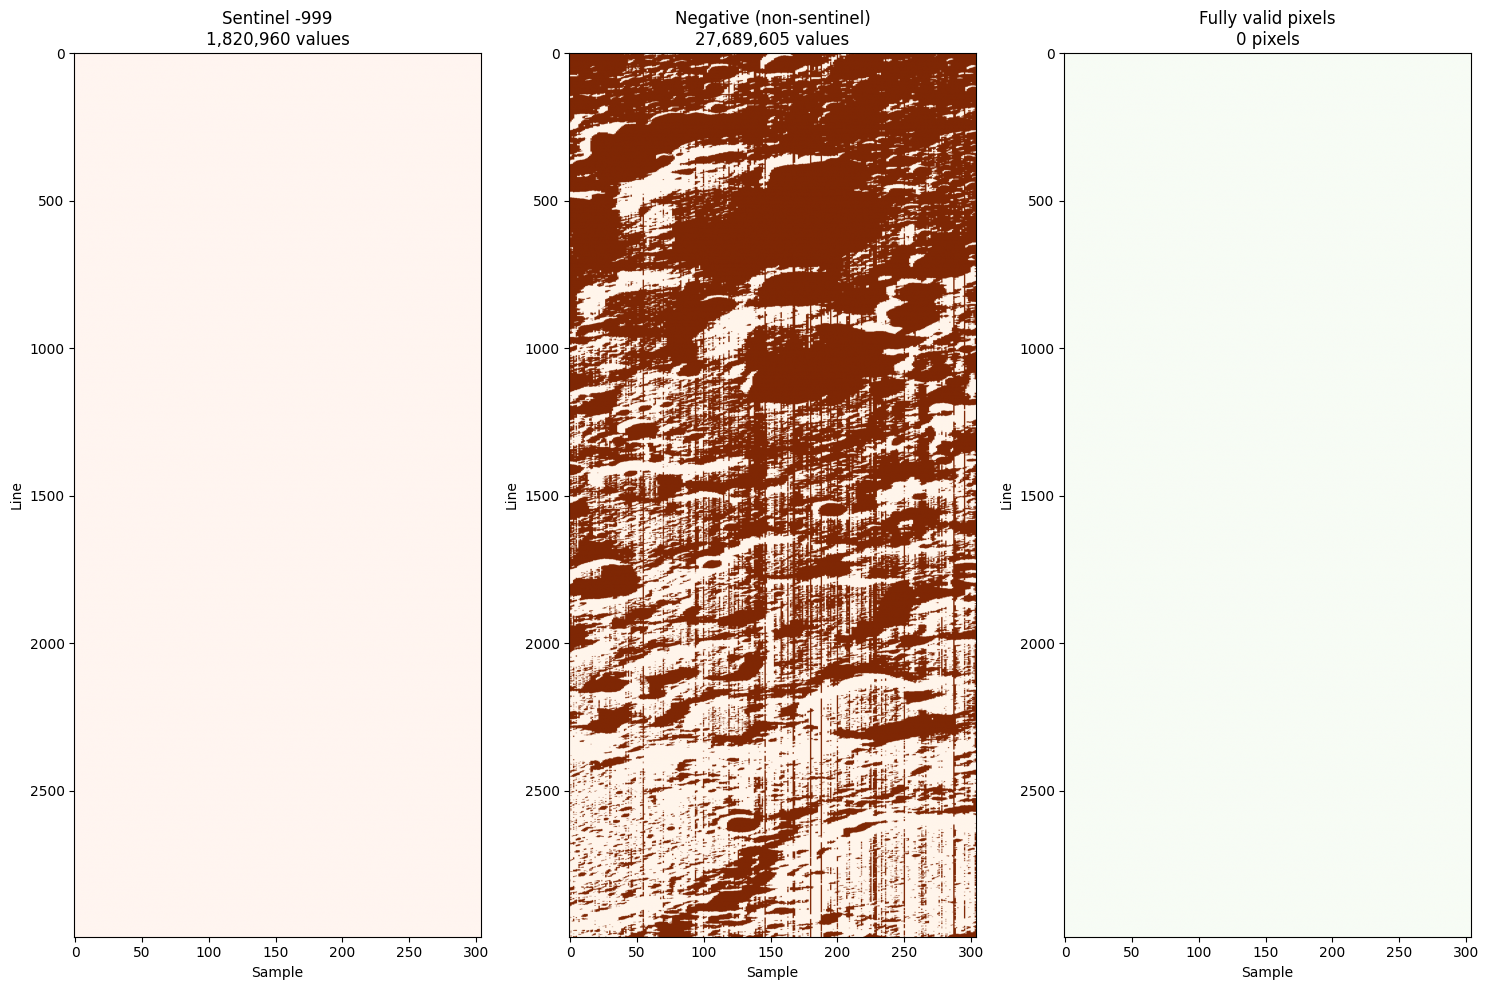

Band |   Sentinel |   Negative |  Valid%
----------------------------------------
   0 |    910,480 |          0 |    0.0%
  10 |          0 |    359,780 |   60.5%
  20 |          0 |    343,543 |   62.3%
  30 |          0 |    302,857 |   66.7%
  40 |          0 |    337,874 |   62.9%
  50 |          0 |    344,395 |   62.2%
  60 |          0 |    304,235 |   66.6%
  70 |          0 |    311,021 |   65.8%
  80 |          0 |    364,020 |   60.0%


In [17]:
import matplotlib.pyplot as plt
import numpy as np

data = chan["Y"]  # (85, 2995, 304)

sentinel_mask  = (data == -999.0)                    # exact sentinel
negative_mask  = (data < 0) & (data != -999.0)       # real negatives
valid_mask     = data >= 0                            # truly valid

# Spatial view — collapse across bands
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

axes[0].imshow(sentinel_mask.any(axis=0),  cmap='Reds',   aspect='auto')
axes[0].set_title(f"Sentinel -999\n{sentinel_mask.sum():,} values")

axes[1].imshow(negative_mask.any(axis=0),  cmap='Oranges', aspect='auto')
axes[1].set_title(f"Negative (non-sentinel)\n{negative_mask.sum():,} values")

axes[2].imshow(valid_mask.all(axis=0),     cmap='Greens',  aspect='auto')
axes[2].set_title(f"Fully valid pixels\n{valid_mask.all(axis=0).sum():,} pixels")

for ax in axes:
    ax.set_xlabel("Sample")
    ax.set_ylabel("Line")

plt.tight_layout()
plt.savefig("data_quality_map.png", dpi=150)
plt.show()

# Per-band breakdown
print(f"{'Band':>4} | {'Sentinel':>10} | {'Negative':>10} | {'Valid%':>7}")
print("-" * 40)
for b in range(0, 85, 10):
    s = (data[b] == -999.0).sum()
    n = ((data[b] < 0) & (data[b] != -999.0)).sum()
    v = 100 * (data[b] >= 0).mean()
    print(f"{b:>4} | {s:>10,} | {n:>10,} | {v:>6.1f}%")

In [19]:
import numpy as np

data = chan["Y"].copy().astype(np.float32)

# Step 1 — Find dead bands (all sentinel)
dead_bands = []
for b in range(data.shape[0]):
    sentinel_frac = (data[b] == -999.0).mean()
    if sentinel_frac > 0.95:
        dead_bands.append(b)

print(f"Dead bands: {dead_bands}")
# Expected: [0] at minimum, possibly others at edges

# Step 2 — Remove dead bands entirely
valid_bands = [b for b in range(data.shape[0]) if b not in dead_bands]
data = data[valid_bands]  # (84, 2995, 304) or fewer
print(f"Shape after removing dead bands: {data.shape}")

# Step 3 — Replace sentinels with NaN
data[data == -999.0] = np.nan

# Step 4 — Per-band offset correction
# Shift so that the 1st percentile of valid pixels = 0
for b in range(data.shape[0]):
    valid = data[b][~np.isnan(data[b])]
    p1 = np.percentile(valid, 1)
    if p1 < 0:
        data[b][~np.isnan(data[b])] -= p1

# Step 5 — Fill remaining NaNs (sentinel locations) with band median
for b in range(data.shape[0]):
    band_median = np.nanmedian(data[b])
    data[b] = np.where(np.isnan(data[b]), band_median, data[b])

# Step 6 — Final clip (removes any residual tiny negatives)
data = np.clip(data, 0, None)

# Step 7 — Per-band min-max normalize
data_norm = np.zeros_like(data, dtype=np.float32)
for b in range(data.shape[0]):
    bmin = data[b].min()
    bmax = data[b].max()
    data_norm[b] = (data[b] - bmin) / (bmax - bmin + 1e-8)

# Final check
print(f"\nFinal shape:    {data_norm.shape}")
print(f"Range:          [{data_norm.min():.4f}, {data_norm.max():.4f}]")
print(f"NaN:            {np.isnan(data_norm).any()}")
print(f"Negative:       {(data_norm < 0).sum()}")
print(f"Valid bands:    {data_norm.shape[0]}")

Dead bands: [0, 1]
Shape after removing dead bands: (83, 2995, 304)

Final shape:    (83, 2995, 304)
Range:          [0.0000, 1.0000]
NaN:            False
Negative:       0
Valid bands:    83


In [20]:
# L changes from 85 → 84 (or fewer if more dead bands found)
L_new = data_norm.shape[0]
print(f"New L = {L_new}")

New L = 83


In [22]:
chan["Y"] = data_norm.astype(np.float32)
chan["C"] = np.array([L_new], dtype=np.uint8)
chan["H"] = np.array([data_norm.shape[1]], dtype=np.uint16)
chan["W"] = np.array([data_norm.shape[2]], dtype=np.uint16)

sio.savemat("../data/chandrayaan_preprocessed.mat", chan)

f:\BS\Miniconda\envs\Corex\Lib\site-packages\scipy\io\matlab\_mio.py:317: MatWriteWarning: Starting field name with a underscore (__header__) is ignored
  MW.put_variables(mdict)
f:\BS\Miniconda\envs\Corex\Lib\site-packages\scipy\io\matlab\_mio.py:317: MatWriteWarning: Starting field name with a underscore (__version__) is ignored
  MW.put_variables(mdict)
f:\BS\Miniconda\envs\Corex\Lib\site-packages\scipy\io\matlab\_mio.py:317: MatWriteWarning: Starting field name with a underscore (__globals__) is ignored
  MW.put_variables(mdict)
